In [74]:
import numpy as np

В цьому домашньому завданні відпрацюємо з вами знання, отримані в модулі зі статистики.

**Завдання 1.** Ми обговорили з Вами на лекції, що велика літера Сігма грецького алфавіту позначає в математиці суму. Знайдіть з використанням Python $\Sigma x$, $\Sigma x^2$, та $\Sigma (x-1)^2$ для наступного набору даних:
`1 3 4`
Виведіть результат кожного обчислення на екран.

In [75]:
# collection = [1, 3, 4]

# collection_sum = sum(collection)
# collection_sum_pow = sum([item ** 2 for item in collection])
# collection_formula = sum([(item - 1) ** 2 for item in collection])

collection = np.array([1, 3, 4])

collection_sum = np.sum(collection)
collection_sum_pow = np.sum(collection ** 2)
collection_formula = np.sum((collection - 1) ** 2)
collection_sum, collection_sum_pow, collection_formula

(np.int64(8), np.int64(26), np.int64(13))

**Завдання 2.** Ми зібрали дані про суму покупок в гривнях 20ма випадково обраними клієнтами в нашому магазині (всього клієнтів у нас більше) за минулий місяць. Вони представлені в змінній `sum_purchases`. Знайдіть **вибіркове середнє** для цих даних кожним з зазначених методів:   

  2.1. без використання жодних бібліотек, користуючись тільки Python.  
  2.2. використовуючи відповідний метод бібліотеки `numpy`.

  Виведіть результат обчислень в кожному з випадків на екран та порівняйте результати. Вони співпадають?

In [76]:
sum_purchases = [ 316,  493,  367,  153,  224,  121,  322,  450,  196,  397,  281,
  239,  484,  124,  223,  448,  432,  255, 4310, 3524]

purchases_len = len(sum_purchases)
purchases_sum = sum(sum_purchases)

In [77]:
purchases_mean = purchases_sum / purchases_len

np.mean(sum_purchases), purchases_mean

(np.float64(667.95), 667.95)

**Завдання 3.** Для того ж набору даних в змінній `sum_purchases` обчисліть **медіану** кожним з зазначених методів:  

  3.1. без використання жодних бібліотек, користуючись тільки Python.  
  3.2. використовуючи відповідний метод бібліотеки numpy.  

Виведіть результат обчислень в кожному з випадків на екран. Порівняйте результати зі значенням вибіркового середнього. Напишіть коментар, для яких задач ви б використовували вибіркове середнє, а для яких - медіану?

In [78]:
def getMedian(array: list):
  new_array = array[:]
  new_array.sort()

  length = len(new_array)
  middle = length // 2

  return (new_array[middle - 1] + new_array[middle]) / 2 if length % 2 == 0 else new_array[middle]

In [79]:
getMedian(sum_purchases), np.median(sum_purchases)

(319.0, np.float64(319.0))

**Завдання 4**. Обчислість стандартне відхилення наведеної вибірки в змінній `sum_purchases` кожним з зазначених методів:  

  4.1. без використання жодних бібліотек, користуючись тільки Python.  
  4.2. використовуючи відповідний метод бібліотеки numpy.  

Виведіть результат обчислень в кожному з випадків на екран.

In [80]:
def getVariance(array: list, ddof: int = 0):
  length = len(array)
  mean = sum(array) / length

  return sum([(i - mean) ** 2 for i in array]) / (length - ddof)

def getStd(array: list, ddof = 0):
  return np.sqrt(getVariance(array, ddof=ddof))

In [81]:
ddof = 0

getStd(sum_purchases, ddof=ddof), np.std(sum_purchases, ddof=ddof)

(np.float64(1096.0692713054227), np.float64(1096.0692713054227))

**Завдання 5**. Ми провели дослідження віку студентів-першокурсників. Виявилось, що
- 10 студентів мають вік 16 років
- 25 студентів - 17 років
- 20 студентів - 18 років
- 2 студенти - 20 років

Обчислість середнє значення для цієї вибірки будь-яким способом - на чистому Python або з numpy - та виведіть результат на екран.

In [91]:
## method 1
students = [16] * 10 + [17] * 25 + [18] * 20 + [20] * 2

## method 2
data = {
    16: 10,
    17: 25,
    18: 20,
    20: 2
}

total_years = sum(age * count for age, count in data.items())

total_students = sum(data.values())

average_age = total_years / total_students

## method 3
ages = np.array([16, 17, 18, 20])

counts = np.array([10, 25, 20, 2])

average_age_np = np.average(ages, weights=counts)

average_age, np.mean(students), average_age_np

(17.280701754385966,
 np.float64(17.280701754385966),
 np.float64(17.280701754385966))

**Завдання 6**. Крім даних про суму покупок, ми зібрали ще дані про кількість відвідувань кожного з кожного покупця, які знаходяться в змінній `visits`. Обчисліть коефіцієнт кореляції Пірсона для суми покупок і кількості відвідувань кожним з зазначених методів:  

  6.1. без використання жодних бібліотек, користуючись тільки Python.  
  6.2. використовуючи відповідний метод бібліотеки numpy.  
  
Виведіть результат на екран. Проаналізуйте результат.

Виведіть додатково графік розсіювання викликавши код нижче і зробіть заключення, чи варто щось змінити при підрахунку кореляції, аби коефіцієнт Пірсона показував коректну оцінку лінійної залежності?

In [82]:
def getCovariance(x: list, y: list, ddof: int = 0):
  x_len, y_len = len(x), len(y)
  x_mean, y_mean = sum(x) / x_len, sum(y) / y_len

  x_dev = [i - x_mean for i in x]
  y_dev = [i - y_mean for i in y]

  result = [xi * yi for xi, yi in zip(x_dev, y_dev)]

  return sum(result) / (len(result) - ddof)

In [83]:
visits = [ 6,  2, 10,  3,  9,  9,  2,  3,  6,  6, 10,  2,  5, 10,  3,  5,  4,
        7,  4,  2]

In [84]:
ddof = 0

getCovariance(sum_purchases, visits) / (getStd(sum_purchases) * getStd(visits)), np.corrcoef(sum_purchases, visits)

(np.float64(-0.3026584468766645),
 array([[ 1.        , -0.30265845],
        [-0.30265845,  1.        ]]))

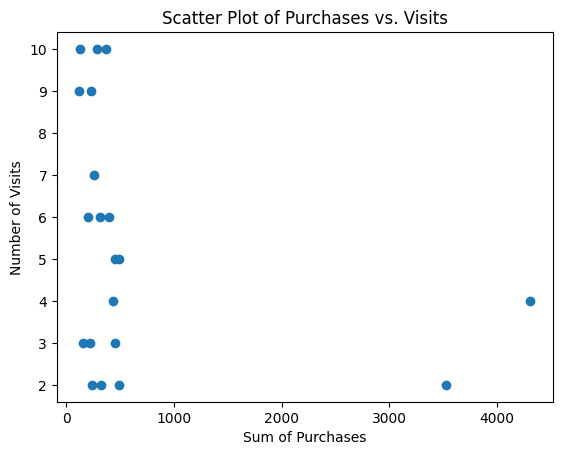

In [85]:
import matplotlib.pyplot as plt

plt.scatter(sum_purchases, visits)
plt.title('Scatter Plot of Purchases vs. Visits')
plt.xlabel('Sum of Purchases')
plt.ylabel('Number of Visits');

**Завдання 7**. В попередньому завданні ми помітили, що викиди нам заважають отримати "правдиве" значення кореляції. Давайте вилучимо записи, які відповідають значенням з викидами в сумі покупок і обчисліть коеф. кореляції. Для цього поставте `threshold`, який дорінює середньому значенню + 2 стандартних вдіхилля суми покупок і всі значення, які більше за нього, будемо вважати викидами (є і інші правила для визначення викидів - з ним и познайомимось пізніше).

Вилучіть значення з обох масивів і обчисліть коеф. кореляції Пірсона з допомогою `numpy` для кількості візитів і суми покупок без записів-викидів. Виведіть результат на екран, побудуйте діаграму розсіювання і проаналізуйте результат: що можемо сказати про залежність в даних?

In [103]:
SP_data = np.array(sum_purchases)
V_data = np.array(visits)

SP_data_mean = np.mean(SP_data)
V_data_mean = np.mean(V_data)
SP_data_std = np.std(SP_data)
V_data_std = np.std(V_data)

SP_data_threshold = SP_data_mean + 2 * SP_data_std
V_data_threshold = V_data_mean + 2 * V_data_std

SP_data = SP_data[SP_data < SP_data_threshold]
V_data = V_data[V_data < V_data_threshold]

min_length = min(len(SP_data), len(V_data)) # Нажаль довжина двух зміних не однакова

In [107]:
np.corrcoef(SP_data[:min_length], V_data[:min_length]) # Як на мене то звʼязок між двома зміними слабкий, але він збільшився коли прибрали "викиди"

array([[ 1.        , -0.36852121],
       [-0.36852121,  1.        ]])

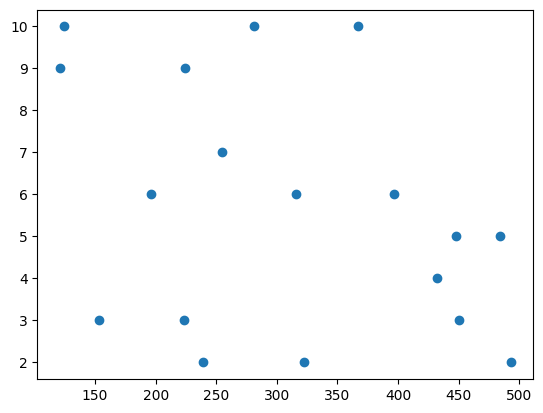

In [106]:
plt.plot(SP_data[:min_length], V_data[:min_length], 'o');